In [4]:
using Pkg
Pkg.activate("TASEP")
Pkg.instantiate()
include("./modules/transcription.jl")
using StatsPlots
using Turing

  Activating project at `C:\Users\ChemeGrad2021\Documents\Braatz Group\MRNA Synthesis\Published code\IVTratelaw\TASEP`


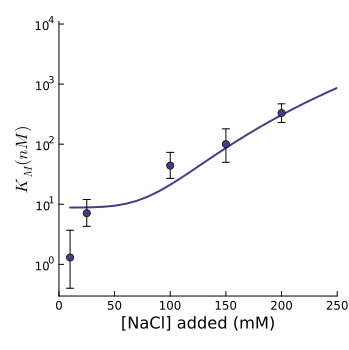

In [6]:
function Ksaltmodel(Mg,Na,Cl,Glu,Tris,param; initsalt = 0)
    n = param.Nf 
    equivNaOAc = (Na)+4.7093*Mg+0.72413*Cl+1.0718*Tris+initsalt
    logKsalt = param.logKf0+n*log(equivNaOAc)
    return exp(logKsalt)
end

function competitiveT7bindingmodel(MgCl2,NaCl,T7,param)#Total cations in M
    Na = NaCl
    Mg = MgCl2
    Cl = 2*MgCl2+NaCl
    K = Ksaltmodel(Mg,Na,Cl,0,0,param)
    return 1/(1+1/(80e-9/K))#Returns fraction of DNA bound by T7
end

function T7bindingresidual(bindingdata, param; T7 = 80e-9, error = 0.1)
    sum = 0
    for (MgCl2, NaCl, bindingratio) in eachrow(bindingdata)
        sum+=(bindingratio - competitiveT7bindingmodel(MgCl2/1000,NaCl/1000,T7,param))^2/(error)^2
    end
    return sum
end

function getMaslakKMD(param,NaCl; K = 0)
    Na = (NaCl+K+4.8)/1000
    Cl = (NaCl+22.5)/1000#Plus from buffer
    Glu = K/1000
    Tris = (40e-3)/2#Buffer
    k_off_adj = 1e9*param.k_on*Ksaltmodel(0,Na,Cl,Glu,0,param)
    K_MD = (k_off_adj+param.k_i)/(param.k_on)
end

function plotMaslakKMD!(plt,param; K=false, color = :red, linewidth = 3)
    saltrange = LinRange(10,400,40)
    if K
        predictedKMD = [getMaslakKMD(param,0,K=salt) for salt in saltrange]
    else
        predictedKMD = [getMaslakKMD(param,salt) for salt in saltrange]
    end
    plot!(plt,saltrange,predictedKMD,color = color,label = "", linewidth = linewidth)
end


k_i = 1800 #From Maslak and Martin
k_on = 10^2.31 #P-DNA binding (hours^-1 nM^-1)
k_off = 10^3.64
logKf0 = -10
fittedparams = ComponentVector((k_on = k_on, k_off = k_off, k_i = k_i, logKf0 = logKf0, Nf = 5.0))



#PlottingMaslak data of KMD values
maslakNaCl = [10,25,100,150,200]
maslakNaClKMD = [1.3,7.1,44,100,330]
maslakuncertaintyNaCllow = [0.9,2.8,17,50,100]
maslakuncertaintyNaClhigh = [2.4,4.9,29,80,140]

maslakKGlu = [10,25,50,100,175,250]
maslakKGluKMD = [0.4,2.2,5.2,2.0,11,26]
maslakuncertaintyKGlulow = [0.3,1.1,2.6,1.2,6.5,19.6]
maslakuncertaintyKGluhigh = [1.6,2.1,4.8,2.2,14,70]

plt_mas = plot(yscale = :log, ylabel = L"K_{M} (nM)", xlabel = "[NaCl] added (mM)", legend = :outerright)
plotMaslakKMD!(plt_mas,fittedparams, color = :slateblue4, linewidth = 2)
scatter!(maslakNaCl,maslakNaClKMD, yerror = (maslakuncertaintyNaCllow, maslakuncertaintyNaClhigh), color = :slateblue4, label = "")
#scatter!(maslakKGlu,maslakKGluKMD, yerror = (maslakuncertaintyKGlulow, maslakuncertaintyKGluhigh), color = :tomato2, label = "Maslak and Martin (1994): KGlu",size = (400,400), legend = :outerbottom)
plot!(grid = false, xlims = (0,250), size = (350,350), legend = :outertop)
plt_mas

In [7]:
function getNaClrate(D, P, NaCl,param; model = InitiationElongationModel())
    Na = NaCl+0.4*20e-3#Sodium we are adding, sodium we use to adjust reaction to desired pH, and sodium from NTPs
    Cl = (21.075e-3*2 + 22.5e-3 + NaCl)#Cl from MgCl2, Cl from Tris HCl buffer, and NaCl we are adding
    Mg = 1.075e-3#Free Mg (rough estimate)
    Tris = (40e-3+3.4*20e-3)/2#HTris from buffer, Tris from NTPs (roughly half is in a cation form at ph 8)
    Glu = 0
    k_off_adj = 1e9*param.k_on*Ksaltmodel(Mg,Na,Cl,Glu,Tris,param)
    K_MD = (param.k_i+k_off_adj)/param.k_on
    params = ComponentVector((k_i = param.k_i, K = K_MD, α = param.α, N_all = 2078))
    DPinputs = reshape([D,P], (1,2))
    return (generatesyntheticdata(model,params,DPinputs,0.0)[1],K_MD)
end

function getNaClrates(D,P,params; model = InitiationElongationModel(), color = :red, linewidth = 0.3, ndisc = 100, NaClrange = LinRange(0,400,ndisc))
    rates = zeros(ndisc)
    for (ind,NaCl) in enumerate(NaClrange)
        rates[ind] = getNaClrate(D,P,NaCl*1e-3,params,model = model)[1]
    end
    return rates ./ maximum(rates)
end

function relative(f, r; sp)
    p = plot!()
    lims = f(p[sp])
    return lims[1] + r * (lims[2]-lims[1])
end

relativex(r; sp::Int=1) = relative(Plots.xlims, r; sp=sp)
relativey(r; sp::Int=1) = relative(Plots.ylims, r; sp=sp)

function processNaClkinetics(kineticdata)
    maxrate = kineticdata[1,3]
    maxuncertainty = kineticdata[1,4]
    NaCl = kineticdata[:,5]
    relrate = kineticdata[:,3]./maxrate
    reluncertainty= relrate .*sqrt.((kineticdata[:,4]./kineticdata[:,3]).^2 .+(maxuncertainty./maxrate)^2)
    reluncertainty[1] = 0.0
    return (NaCl,relrate,reluncertainty)
end

function plotNaClmodel!(plt,logKf0,D,P,model,color,thinparams;ndisc = 500,NaClrange = LinRange(0,400,ndisc))
    k_on = 10^2.31 #P-DNA binding (hours^-1 nM^-1)
    k_off = 10^3.64
    fittedparams = ComponentVector((k_on = k_on, k_i = thinparams[1], logKf0 = logKf0, Nf = 5.0, α = thinparams[2]))
    rates = getNaClrates(D,P,fittedparams, model = model, ndisc = ndisc, NaClrange = NaClrange)
    plot!(plt,NaClrange, rates, color = color, label="",z_order = :back,linewidth = 1.5)
end

function getzeroKMD(logKf0,model,thinparams)
    k_on = 10^2.31 #P-DNA binding (hours^-1 nM^-1)
    k_off = 10^3.64
    fittedparams = ComponentVector((k_on = k_on, k_i = thinparams[1], logKf0 = logKf0, Nf = 5.0, α = thinparams[2]))
    getNaClrate(100, 100, 0,fittedparams; model = model)[2]
end

getzeroKMD (generic function with 1 method)

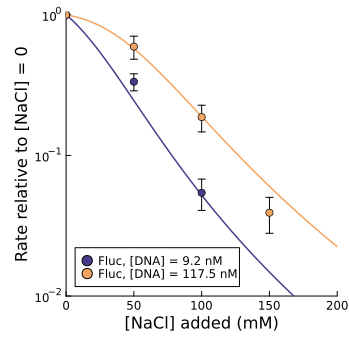

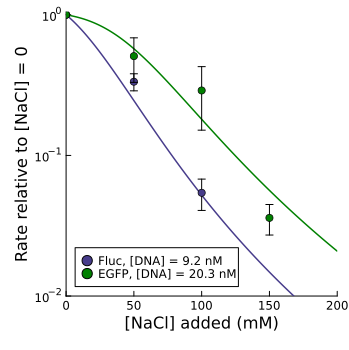

Fluc K_MD at zero NaCl added = 62.6 nM
EGFP K_MD at zero NaCl added = 30.6 nM


In [8]:
model = InitiationElongationModel()

Flucp =  [1222.2, 9.72864173038237]
FluclogKf0 = log(2.5e-3)

EGFPp = [2790.2, 15.1]
EGFPlogKf0 = log(0.75e-3)

#Internal Fluc kinetic data
NaClkineticdatadf = CSV.read("data_processing/output/Fluc NaCl/FlucNaCl_PDS_V2_Nathan.csv", DataFrame)
FlucNaClkineticdata = Matrix(NaClkineticdatadf)
FlucNaClkineticdatalowDNA = FlucNaClkineticdata[1:4,:] 
FlucNaClkineticdatahighDNA = FlucNaClkineticdata[5:end,:] 
initlimitedD = 9.2
initlimitedP = 192
elonglimitedD = 117.5
elonglimitedP = 192
fontsize = 20
(FlucNaCllowDNA,FlucrelratelowDNA,FlucreluncertaintylowDNA) = processNaClkinetics(FlucNaClkineticdatalowDNA)
(FlucNaClhighDNA,FlucrelratehighDNA,FlucreluncertaintyhighDNA) = processNaClkinetics(FlucNaClkineticdatahighDNA)

#Internal EGFP Kinetic Data
EGFPNaClkineticdatadf = CSV.read("data_processing/output/EGFP NaCl/EGFPNaClExperimentIE_Conditions_V2.csv", DataFrame)
EGFPNaClkineticdata = Matrix(EGFPNaClkineticdatadf)
(EGFPNaCl,EGFPrelrate,EGFPreluncertainty) = processNaClkinetics(EGFPNaClkineticdata)



pltNaCl = plot(grid = false)
scatter!(FlucNaCllowDNA,FlucrelratelowDNA,yerror = FlucreluncertaintylowDNA, color = :slateblue4, label = "Fluc, [DNA] = 9.2 nM")
scatter!(FlucNaClhighDNA,FlucrelratehighDNA,yerror = FlucreluncertaintyhighDNA, color = :sandybrown, label = "Fluc, [DNA] = 117.5 nM")
plotNaClmodel!(pltNaCl,FluclogKf0,initlimitedD,initlimitedP,model,:slateblue4,Flucp)
plotNaClmodel!(pltNaCl,FluclogKf0,elonglimitedD,elonglimitedP,model,:sandybrown,Flucp)
plot!(yscale = :log, ylims = (0.01,1.05), xlims = (0,200), ylabel = "Rate relative to [NaCl] = 0", xlabel = "[NaCl] added (mM)", size = (350,350))
savefig(pltNaCl,"figures/NaClmaster.png")
display(pltNaCl)

egfpD = 20.3
egfpP = 9.2
pltFluc_EGFP = plot(grid = false)
scatter!(FlucNaCllowDNA,FlucrelratelowDNA,yerror = FlucreluncertaintylowDNA, color = :slateblue4, label = "Fluc, [DNA] = 9.2 nM")
scatter!(EGFPNaCl,EGFPrelrate,yerror = EGFPreluncertainty, color = :green, label = "EGFP, [DNA] = 20.3 nM")
plotNaClmodel!(pltFluc_EGFP,FluclogKf0,initlimitedD,initlimitedP,model,:slateblue4,Flucp)
plotNaClmodel!(pltFluc_EGFP,EGFPlogKf0,egfpD,egfpP,model,:green,EGFPp)
plot!(yscale = :log, ylims = (0.01,1.05), xlims = (0,200), ylabel = "Rate relative to [NaCl] = 0", xlabel = "[NaCl] added (mM)", size = (350,350))
savefig(pltNaCl,"figures/NaClmaster.png")
display(pltFluc_EGFP)

println("Fluc K_MD at zero NaCl added = "*string(round(getzeroKMD(FluclogKf0,model,Flucp),digits = 1))*" nM")
println("EGFP K_MD at zero NaCl added = "*string(round(getzeroKMD(EGFPlogKf0,model,EGFPp),digits = 1))*" nM")


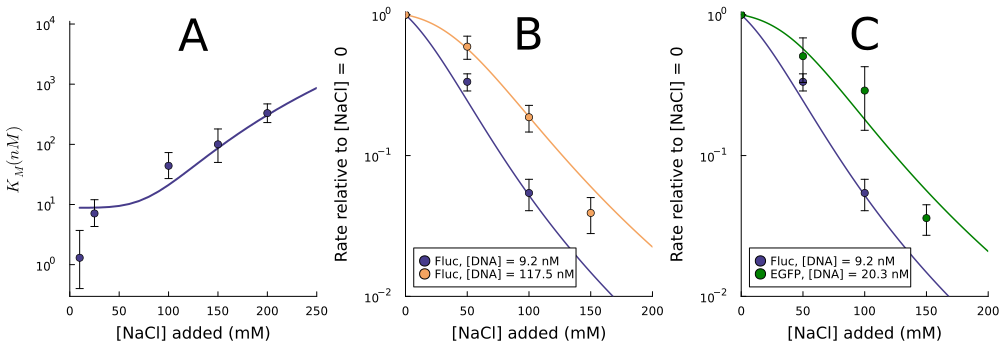

In [9]:
masterplot = plot(plt_mas,pltNaCl,pltFluc_EGFP,size = (1000,350),layout = (1,3), bottommargin = 6mm, leftmargin = 5mm)
fontsize = 30
annotate!(sp=1,[(relativex(0.5; sp=1), relativey(0.6; sp=1), text("A",fontsize))],z_order = :front)
annotate!(sp=2,[(relativex(0.5; sp=2), relativey(0.7; sp=2), text("B",fontsize))],z_order = :front)
annotate!(sp=3,[(relativex(0.5; sp=3), relativey(0.7; sp=3), text("C",fontsize))],z_order = :front)
savefig(masterplot,"figures/pubfigs/NaClmaster.png")
savefig(masterplot,"figures/pubfigs/NaClmaster.pdf")
masterplot